<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Codependence: KSG mutual information and distance correlation
    </h1>
  </div>
</div>

De Prado's codependence kernel estimates **mutual information from a binned
histogram**, whose bias and variance grow as the sample shrinks relative to the
bin count and which depends on an arbitrary bin choice. Two binning-free
alternatives: the **Kraskov-Stogbauer-Grassberger (KSG)** kNN estimator (adaptive
distances, far less biased on short/nonlinear samples) and **distance
correlation** (a tuning-free nonlinear dependence index in [0,1]).

*Baseline (binned MI) -> where it breaks (short / nonlinear) -> KSG / dCor.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Data: ksg_mutual_information, distance_correlation,
    calculate_mutual_information

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. Three dependence structures
Linear, nonlinear (`y = x^2`), and independent.

In [2]:
rng = MersenneTwister(0)
n = 800
x = randn(rng, n)
y_lin = 0.8 .* x .+ 0.2 .* randn(rng, n)
y_non = x .^ 2 .+ 0.3 .* randn(rng, n)
y_ind = randn(rng, n)
for (name, yy) in (("linear", y_lin), ("nonlinear (x^2)", y_non), ("independent", y_ind))
    println(rpad(name, 18),
            " KSG MI=", round(ksg_mutual_information(x, yy), digits = 3),
            "   dCor=", round(distance_correlation(x, yy), digits = 3),
            "   binned MI=", round(calculate_mutual_information(x, yy), digits = 3))
end

linear             KSG MI=1.512   dCor=0.959   binned MI=1.321
nonlinear (x^2)    KSG MI=1.082   dCor=0.516   binned MI=0.584
independent        KSG MI=0.009   dCor=0.054   binned MI=0.034


## 2. KSG is far less biased on small samples
We track MI of a strongly-dependent pair as the sample shrinks; the binned
estimator's bias grows while KSG stays stable.

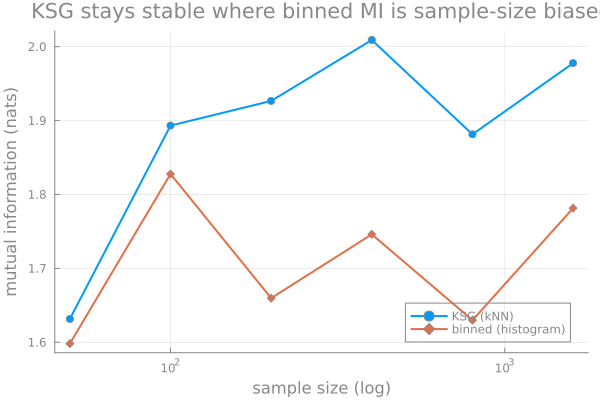

In [3]:
sizes = [50, 100, 200, 400, 800, 1600]
ksg = Float64[]; binned = Float64[]
for m in sizes
    rng2 = MersenneTwister(m)
    z = randn(rng2, m)
    xa = z .+ 0.1 .* randn(rng2, m); ya = z .+ 0.1 .* randn(rng2, m)
    push!(ksg, ksg_mutual_information(xa, ya))
    push!(binned, calculate_mutual_information(xa, ya))
end
plot(sizes, ksg; label = "KSG (kNN)", lw = 2, marker = :circle, xscale = :log10,
     xlabel = "sample size (log)", ylabel = "mutual information (nats)",
     title = "KSG stays stable where binned MI is sample-size biased")
plot!(sizes, binned; label = "binned (histogram)", lw = 2, marker = :diamond)

## When to use / when NOT (from `appraisals/11_verdict.md`)
**Prefer KSG over binned MI/VI on short, noisy, or nonlinear / heavy-tailed
samples**; it is essentially unbiased on linear dependence and *converges* to
binned on large near-linear data (no free lunch there). Use raw KSG (the surrogate
de-bias adds nothing). **Prefer distance correlation as a parameter-free nonlinear
screen / for maximally stable clustering.** It is a dependence index, not a metric
on partitions like VI - keep VI/KSG for the metric role.